In [ ]:
import pandas as pd
df = pd.read_csv('data/train.csv')
# Esto imprime la longitud real de la tabla (número de filas totales)
print(len(df))

1460


### Valores Nulos

In [ ]:
valores_nulos = df.isnull().sum()
columnas_con_nulos = valores_nulos[valores_nulos > 0]
columnas_con_nulos_ordenados = columnas_con_nulos.sort_values(ascending=False)
porcentaje_nulos = (columnas_con_nulos_ordenados / len(df)) * 100
tabla_nulos = pd.DataFrame({
    'Total Nulos': columnas_con_nulos_ordenados,
    'Porcentaje': porcentaje_nulos.round(2)
})
print('Columnas con datos faltantes detectadas')
display(tabla_nulos)

Columnas con datos faltantes detectadas


,Total Nulos,Porcentaje
PoolQC,1453,99.52
MiscFeature,1406,96.30
Alley,1369,93.77
Fence,1179,80.75
MasVnrType,872,59.73
FireplaceQu,690,47.26
LotFrontage,259,17.74
GarageType,81,5.55
GarageYrBlt,81,5.55
GarageFinish,81,5.55


### Outliers

In [ ]:
# 1. Volvemos a hacer la copia limpia
df_clean = df.copy()

categoricas_ninguno = [
    'PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
    'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
    'BsmtExposure', 'BsmtFinType2', 'BsmtQual', 'BsmtCond', 'BsmtFinType1',
    'MasVnrType'
]

# ¡Aquí está la corrección! Añadimos el "df_clean[col] =" antes de aplicar el fillna
for col in categoricas_ninguno:
    df_clean[col] = df_clean[col].fillna('None')

# El resto de numéricas que ya tenías bien:
df_clean['GarageYrBlt'] = df_clean['GarageYrBlt'].fillna(0)
df_clean['MasVnrArea'] = df_clean['MasVnrArea'].fillna(0)

mediana_fachada = df_clean['LotFrontage'].median()
df_clean['LotFrontage'] = df_clean['LotFrontage'].fillna(mediana_fachada)

moda_electrica = df_clean['Electrical'].mode()[0]
df_clean['Electrical'] = df_clean['Electrical'].fillna(moda_electrica)

# ELIMINACIÓN DE OUTLIERS

# Filtramos el dataset para quedarnos SOLO con las casas que tengan 
# menos de 4000 pies cuadrados de superficie habitable.
df_clean = df_clean[df_clean['GrLivArea'] < 4000]

# COMPROBACIÓN FINAL

nulos_restantes = df_clean.isnull().sum().sum()
total_filas_actuales = df_clean.shape[0]

print(f"✅ ¡Limpieza completada! Valores nulos restantes: {nulos_restantes}")
print(f"🏠 Casas restantes en el dataset (tras eliminar outliers): {total_filas_actuales}")

✅ ¡Limpieza completada! Valores nulos restantes: 0
🏠 Casas restantes en el dataset (tras eliminar outliers): 1456


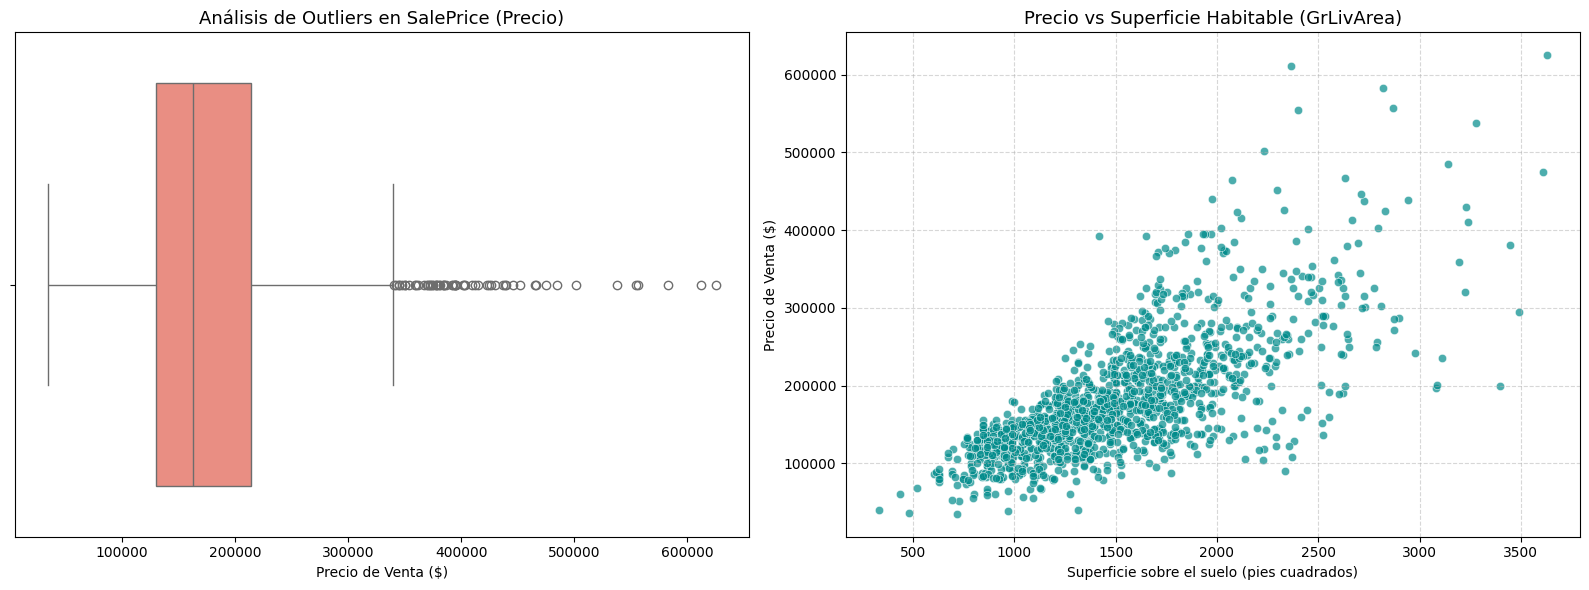

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

#Creamos un lienzo con dos subgraficos
fig, axes = plt.subplots(1, 2, figsize=(16,6))

#Grafico de caja para detectar outliers en el precio
sns.boxplot(ax=axes[0], x=df_clean["SalePrice"], color="salmon")
axes[0].set_title("Análisis de Outliers en SalePrice (Precio)", fontsize=13)
axes[0].set_xlabel("Precio de Venta ($)")

#Grafico de dispersion para outliers de tamaño vs precio
sns.scatterplot(ax=axes[1], x=df_clean["GrLivArea"], y=df_clean["SalePrice"], alpha=0.7, color="darkcyan")
axes[1].set_title("Precio vs Superficie Habitable (GrLivArea)", fontsize=13)
axes[1].set_xlabel("Superficie sobre el suelo (pies cuadrados)")
axes[1].set_ylabel("Precio de Venta ($)")
axes[1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

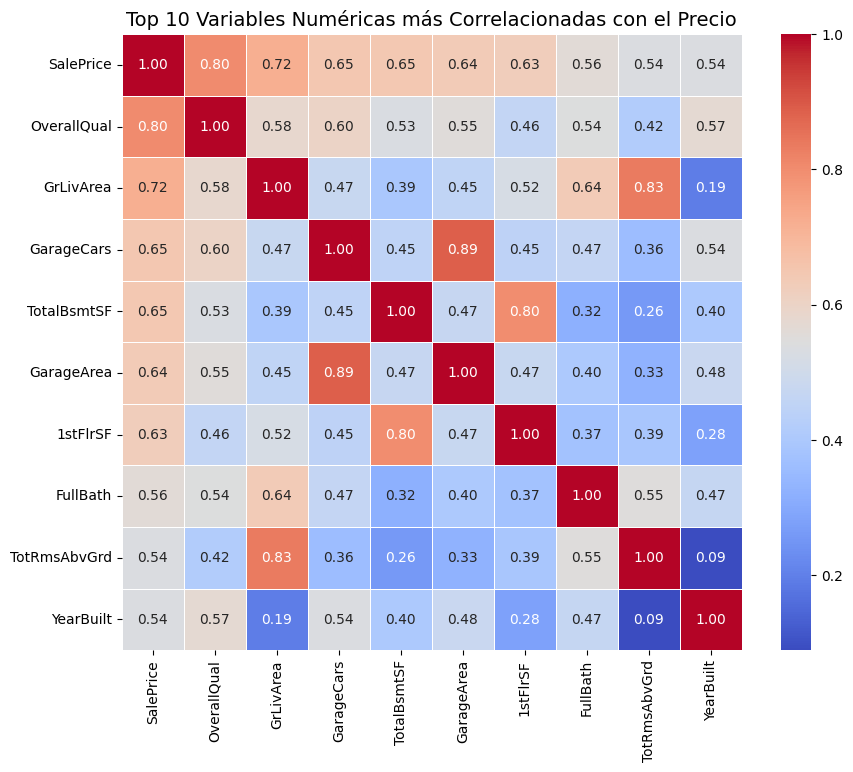

In [ ]:
import numpy as np

#Filtramos solo columnas numericas(ya que la correlacion solo funciona con numeros)
df_numerico = df_clean.select_dtypes(include=[np.number])

#Calcular matriz de correlacion
matriz_corr = df_numerico.corr()

#Extraer la correlacion de todas las variables con respecto a SalePrice
#Se ordenan de mayor a menos y nos quedamos con las 10 primeras
top_10_variables = matriz_corr["SalePrice"].sort_values(ascending=False).index[:10]

#Dibujar heatmap en base al top 10
plt.figure(figsize=(10, 8))
sns.heatmap(
    df_clean[top_10_variables].corr(), 
    annot=True,          # Añade el número de correlación dentro de cada cuadro
    cmap="coolwarm",     # Escala de color (azul=negativo, rojo=positivo)
    fmt=".2f",           # Limita a 2 decimales
    linewidths=0.5       # Añade una línea fina de separación entre cuadros
)

plt.title("Top 10 Variables Numéricas más Correlacionadas con el Precio", fontsize=14)
plt.show()

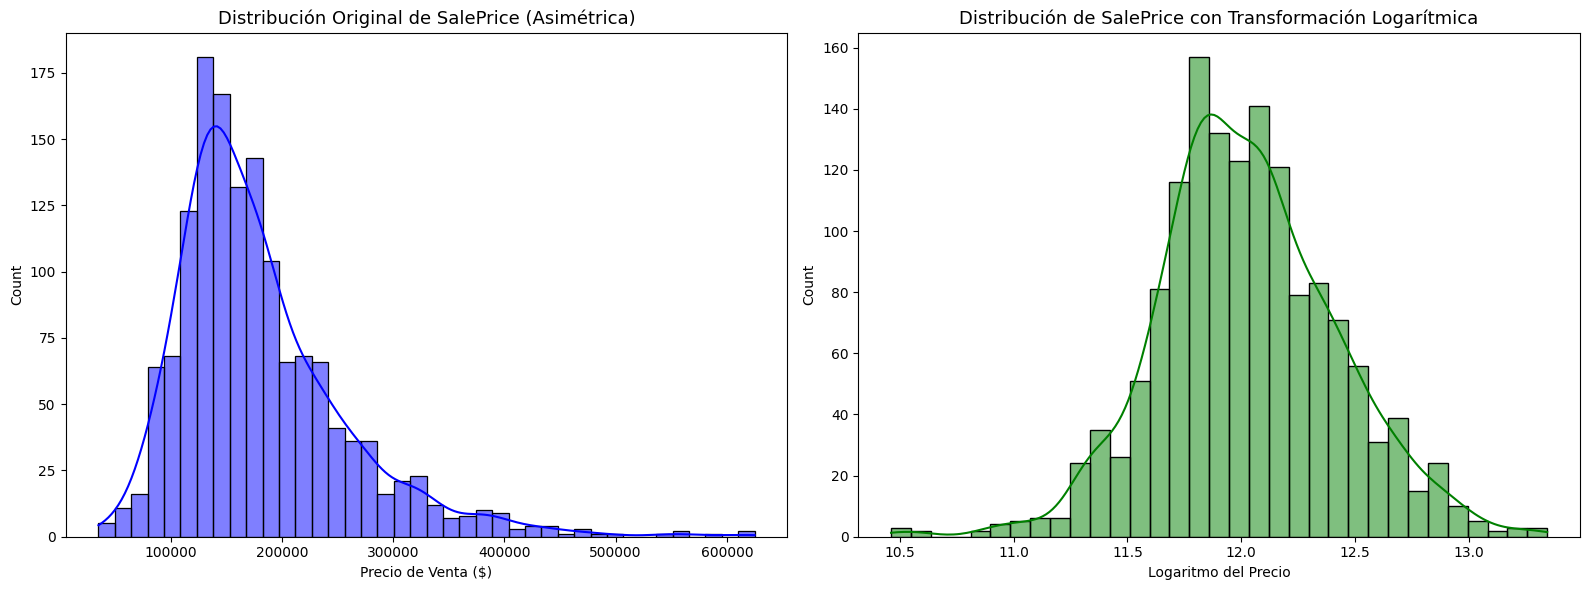

In [ ]:
import numpy as np

#Aplicamos transformacion logaritmica
df_clean["SalePrice_Log"] = np.log1p(df_clean["SalePrice"])

#creamos un lienzo para comparar ambas distribuciones
fig,axes = plt.subplots(1,2, figsize = (16,6))

# Gráfica Izquierda: Distribución Original (Sesgada)
sns.histplot(ax=axes[0], data=df_clean, x="SalePrice", kde=True, color="blue")
axes[0].set_title("Distribución Original de SalePrice (Asimétrica)", fontsize=13)
axes[0].set_xlabel("Precio de Venta ($)")

# Gráfica Derecha: Nueva Distribución Logarítmica (Normalizada)
sns.histplot(ax=axes[1], data=df_clean, x="SalePrice_Log", kde=True, color="green")
axes[1].set_title("Distribución de SalePrice con Transformación Logarítmica", fontsize=13)
axes[1].set_xlabel("Logaritmo del Precio")

plt.tight_layout()
plt.show()